<a href="https://colab.research.google.com/github/seforarosenberg25/css-therapygpt-bertopic/blob/main/Final_TherapyGPT_bertopic_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BERTopic — with BERT Embeddings
**Corpus:** **Corpus:** r/TherapyGPT — Absätze aus Posts mit Flair "Personal Story"
**Embedding model:** `sentence-transformers/all-mpnet-base-v2`

### What this notebook does
1. Load corpus
2. Embed documents with MPNet (contextual, not bag of words)
3. Reduce dimensions with UMAP
4. Cluster with HDBSCAN — K emerges from the data
5. Represent topics with c-TF-IDF
6. Inspect and visualise results

## 0. Imports and setup

In [1]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.7 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from google.colab import drive

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

import matplotlib.pyplot as plt
import matplotlib as mpl

# Mount Google Drive
drive.mount('/content/drive/')

# ── Angepasst auf euren TherapyGPT-Korpus ────────────────────────────
DATA_PATH = Path('/content/drive/MyDrive/reddit_therapygpt_paragraphs.parquet')
if not DATA_PATH.exists():
    DATA_PATH = DATA_PATH.with_suffix('.csv')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'Data   : {DATA_PATH}')

Mounted at /content/drive/
Device : cuda
Data   : /content/drive/MyDrive/reddit_therapygpt_paragraphs.parquet


## 1. Load corpus

In [3]:
from pathlib import Path

# Correcting DATA_PATH as it seems to be defined incorrectly in the previous cell
# The files are directly under MyDrive, not in a 'crypto_corpus' subfolder.
DATA_PATH = Path('/content/drive/MyDrive/reddit_therapygpt_paragraphs.parquet')
if not DATA_PATH.exists():
    DATA_PATH = DATA_PATH.with_suffix('.csv')

df = (pd.read_parquet(DATA_PATH) if DATA_PATH.suffix == '.parquet'
      else pd.read_csv(DATA_PATH, parse_dates=['created_utc']))

print(f'Absätze gesamt : {len(df):,}')
print(df['flair'].value_counts().to_string())

# ── Filter auf "Personal Story" (Vorgabe Prof. Filippe) ──────────────
df = df[df['flair'] == 'Personal Story'].reset_index(drop=True).copy()
print(f'\nAbsätze nach Filter : {len(df):,}')

docs = df['paragraph_text'].tolist()

Absätze gesamt : 6,524
flair
Personal Story                                       565
Commentary                                           491
Seeking Advice                                       387
Prompt/Workflow Sharing                              352
Seeking Advice/Question For Others                   214
Safety Concern                                       174
News                                                 164
Unique Use-Case                                       88
Fun                                                   42
? for Therapists/Coaches/Peer Support Specialists     35
Discussion                                            11
Meta                                                   8
Poll                                                   3

Absätze nach Filter : 565


In [4]:
for c in df.columns:
    print(f'{c:20} | Beispiel: {str(df[c].iloc[0])[:60]}')

post_id              | Beispiel: 1uubrcp
paragraph_id         | Beispiel: 1uubrcp_0
paragraph_index      | Beispiel: 0
subreddit            | Beispiel: TherapyGPT
stance               | Beispiel: pro
flair                | Beispiel: Personal Story
title                | Beispiel: Don't use DeepSeek
paragraph_text       | Beispiel: I'm going through a really difficult divorce, and I tried ta
word_count           | Beispiel: 66
score                | Beispiel: 1
num_comments         | Beispiel: 0
created_utc          | Beispiel: 2026-07-12


In [5]:
print(df['stance'].value_counts().to_string())

stance
pro    565


In [6]:
print(df['word_count'].value_counts().sort_index().head(8).to_string())

word_count
15    15
16    10
17    16
18     7
19     8
20    10
21     8
22    10


## 1b. Korpusbeschreibung und Datenqualität
Kennzahlen für den Methodenteil sowie Prüfung auf Duplikate und Überlänge
(das Embedding-Modell verarbeitet maximal 384 Wortstücke).

In [7]:
# Zeitraum und Umfang
if 'created_utc' in df.columns:
    print(f'Zeitraum : {df["created_utc"].min()}  bis  {df["created_utc"].max()}')
print(f'Posts    : {df["post_id"].nunique():,}')
print(f'Absätze  : {len(df):,}')
print(f'Absätze pro Post (Median) : {df.groupby("post_id").size().median():.1f}')

# Absatzlängen
lengths = df['paragraph_text'].str.split().str.len()
print('\nAbsatzlänge in Wörtern:')
print(lengths.describe().round(1).to_string())
print(f'Absätze über 300 Wörtern : {(lengths > 300).sum()}')

# Duplikate
dupes = df['paragraph_text'].duplicated().sum()
print(f'\nExakte Duplikate : {dupes}')
if dupes:
    print(df['paragraph_text'].str[:80].value_counts().head(10).to_string())

# Verfügbare Spalten (zur Klärung, ob Kommentare enthalten sind)
print(f'\nSpalten : {list(df.columns)}')

Zeitraum : 2026-02-09  bis  2026-07-12
Posts    : 125
Absätze  : 565
Absätze pro Post (Median) : 4.0

Absatzlänge in Wörtern:
count    565.0
mean      52.3
std       42.7
min       15.0
25%       28.0
50%       42.0
75%       63.0
max      514.0
Absätze über 300 Wörtern : 2

Exakte Duplikate : 0

Spalten : ['post_id', 'paragraph_id', 'paragraph_index', 'subreddit', 'stance', 'flair', 'title', 'paragraph_text', 'word_count', 'score', 'num_comments', 'created_utc']


## 2. Embedding model — `sentence-transformers/all-mpnet-base-v2`
`all-mpnet-base-v2` provides the best quality for general-purpose semantic similarity tasks in the `sentence-transformers` library while remaining efficient enough for standard GPU runtimes.

In [8]:
EMBEDDING_MODEL = 'sentence-transformers/all-mpnet-base-v2'

print(f'Loading {EMBEDDING_MODEL}...')
embedding_model = SentenceTransformer(
    EMBEDDING_MODEL,
    trust_remote_code=False,
    device=DEVICE,
)
print(f'Embedding dim : {embedding_model.get_sentence_embedding_dimension()}')

Loading sentence-transformers/all-mpnet-base-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dim : 768


## 3. Pre-compute embeddings
We do this once and pass them to BERTopic — avoids re-embedding if you
experiment with different UMAP / HDBSCAN settings.

In [9]:
import torch

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache cleared before embedding.")

# Create output directory if it doesn't exist to avoid FileNotFoundError
OUT_DIR = Path('./therapygpt_output')
OUT_DIR.mkdir(exist_ok=True)

print(f'Embedding {len(docs):,} documents...')
embeddings = embedding_model.encode(
    docs,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True,
)
print(f'Embeddings shape: {embeddings.shape}')

EMBED_PATH = OUT_DIR / 'all_mpnet_embeddings.npy'
np.save(EMBED_PATH, embeddings)
print(f'Saved → {EMBED_PATH}')

CUDA cache cleared before embedding.
Embedding 565 documents...


Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Embeddings shape: (565, 768)
Saved → therapygpt_output/all_mpnet_embeddings.npy


In [10]:
# To reload cached embeddings on subsequent runs:
# embeddings = np.load(EMBED_PATH)

## 4. Configure pipeline components
Each stage has its own hyperparameters.
**Fix all random seeds** — BERTopic has three stochastic stages.

In [11]:
# ── UMAP: dimensionality reduction ────────────────────────────────────────────
# n_neighbors controls local vs global structure preservation.
# n_components = 5 is typical for BERTopic (not 2 — that is only for visualisation).
# min_dist = 0.0 encourages tighter clusters.
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42,
    low_memory=True,
)

# ── HDBSCAN: density-based clustering ─────────────────────────────────────────
# min_cluster_size controls K indirectly — larger = fewer, bigger topics.
# Kleinerer Wert, da der Personal-Story-Teilkorpus nur 565 Absätze umfasst.
# prediction_data=True enables soft cluster probabilities.
hdbscan_model = HDBSCAN(
    min_cluster_size=15,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
)

# ── CountVectorizer for c-TF-IDF representations ──────────────────────────────
# Domain-spezifische Stoppwörter betreffen nur die Topic-Darstellung,
# nicht das Clustering (das läuft auf den Embeddings).
STOP_EXTRA = [
    'reddit', 'post', 'comment', 'thread', 'edit', 'update',
    'would', 'could', 'also', 'one', 'get', 'got', 'like',
    'know', 'think', 'people', 'thing', 'way', 'just', 'really',
    'ai', 'therapy', 'therapist', 'therapists', 'therapies',
        'im', 'ive', 'id', 'ill', 'dont', 'didnt', 'doesnt', 'cant', 'wont',
    'wasnt', 'isnt', 'arent', 'havent', 'hasnt', 'couldnt', 'wouldnt',
    'shouldnt', 'thats', 'whats', 'theres', 'youre', 'theyre', 'youve',
    'chatgpt', 'gpt', 'gemini', 'claude', 'openai', 'anthropic', 'pro',
    'use', 'using','help', 'feel','thought',
    'don', 'didn', 've', 're', 'll', 'ain', 'isn', 'wasn', 'doesn', 'couldn', 'wouldn', 'shouldn',
]

from sklearn.feature_extraction import text as sk_text

cv = CountVectorizer(
    stop_words=list(sk_text.ENGLISH_STOP_WORDS) + STOP_EXTRA,
    ngram_range=(1, 2),
)

## 5. Fit BERTopic
We pass the pre-computed embeddings so the model skips the embedding step.

In [12]:
topic_model = BERTopic(
    embedding_model=embedding_model,    # used only if you call fit without embeddings
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=cv,
    nr_topics=None,                     # kein Merging — Cluster kommen direkt aus HDBSCAN
    calculate_probabilities=True,
    verbose=True,
)

print('Fitting BERTopic...')
topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)

print(f'\nTopics found : {len(set(topics)) - 1}  (excluding noise cluster −1)')
print(f'Noise docs   : {sum(t == -1 for t in topics):,}  '
      f'({sum(t == -1 for t in topics) / len(topics):.1%} of corpus)')

2026-09-17 17:45:03,323 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting BERTopic...


2026-09-17 17:45:26,932 - BERTopic - Dimensionality - Completed ✓
2026-09-17 17:45:26,941 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-17 17:45:27,125 - BERTopic - Cluster - Completed ✓
2026-09-17 17:45:27,136 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-17 17:45:27,354 - BERTopic - Representation - Completed ✓



Topics found : 6  (excluding noise cluster −1)
Noise docs   : 261  (46.2% of corpus)


## 6. Topic overview

In [13]:
info = topic_model.get_topic_info()
print(info[info['Topic'] != -1].to_string(index=False))

 Topic  Count                               Name                                                                            Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

## 6b. Stabilitätsprüfung (Seed-Variation)
Die Pipeline enthält mit UMAP eine stochastische Komponente. Um zu prüfen,
wie stark die Lösung vom Zufallsstartwert abhängt, wird das Modell mit fünf
verschiedenen Seeds gefittet. Das Hauptmodell (Seed 42) bleibt davon unberührt.

In [14]:
import warnings
warnings.filterwarnings('ignore')

for seed in [0, 1, 42, 123, 2024]:
    u = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
             metric='cosine', random_state=seed, low_memory=True)
    h = HDBSCAN(min_cluster_size=15, metric='euclidean',
                cluster_selection_method='eom', prediction_data=True)
    m = BERTopic(umap_model=u, hdbscan_model=h, vectorizer_model=cv,
                 nr_topics=None, verbose=False)
    t, _ = m.fit_transform(docs, embeddings=embeddings)
    words = [', '.join(w for w, _ in m.get_topic(i)[:3])
             for i in range(len(set(t)) - 1)]
    print(f'seed {seed:4d}: {len(set(t)) - 1} Topics, '
          f'{sum(x == -1 for x in t) / len(t):.1%} Noise')
    for i, w in enumerate(words):
        print(f'           T{i}: {w}')
    print()

seed    0: 6 Topics, 34.3% Noise
           T0: chat, helpful, things
           T1: health, human, mental
           T2: life, shelf, problem
           T3: years, bpd, person
           T4: best, best friend, friend
           T5: conversation, story, did

seed    1: 5 Topics, 35.8% Noise
           T0: life, years, work
           T1: chat, helpful, better
           T2: health, mental, experience
           T3: things, thoughts, emotional
           T4: conversation, story, did

seed   42: 6 Topics, 46.2% Noise
           T0: chat, helpful, better
           T1: health, say, mental
           T2: shelf, life, problem
           T3: years, work, person
           T4: best, best friend, friend
           T5: privacy, support, apps

seed  123: 3 Topics, 25.3% Noise
           T0: life, years, work
           T1: chat, things, support
           T2: health, human, mental

seed 2024: 7 Topics, 45.8% Noise
           T0: chat, helpful, helped
           T1: health, human, experience
    

## 7. Inspect individual topics
c-TF-IDF gives you the words that are most *distinctive* for each cluster —
frequent within the cluster but rare across all other clusters.

In [15]:
top_n = min(10, len(info[info['Topic'] != -1]))

for tid in range(top_n):
    words = [w for w, _ in topic_model.get_topic(tid)]
    print(f'Topic {tid:2d}  ({info.loc[info["Topic"]==tid, "Count"].values[0]:,} docs):  '
          f'{", ".join(words[:8])}')

Topic  0  (79 docs):  chat, helpful, better, helped, actually, things, memory, shadow
Topic  1  (70 docs):  health, say, support, mental, want, mental health, human, work
Topic  2  (69 docs):  shelf, life, problem, feeling, time, childhood, inside, context
Topic  3  (49 docs):  years, work, person, life, abusive, understand, learned, left
Topic  4  (20 docs):  best friend, best, friend, boundary, internal, toxic, trauma, uses
Topic  5  (17 docs):  privacy, support, apps, things, thoughts, built, chats, build


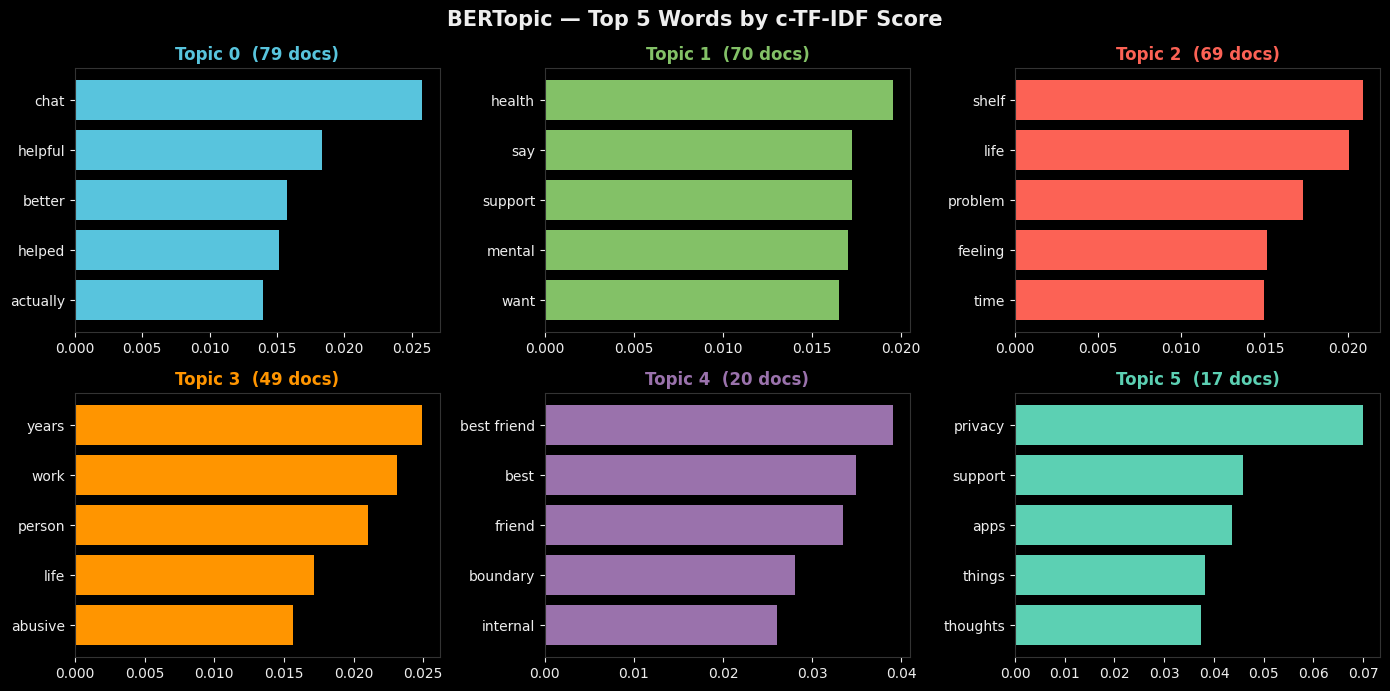

In [16]:
# Bar chart: top 5 words for the first 6 topics
mpl.rcParams.update({'figure.facecolor': '#000000', 'axes.facecolor': '#000000',
                     'text.color': '#EEEEEE', 'axes.labelcolor': '#EEEEEE',
                     'xtick.color': '#EEEEEE', 'ytick.color': '#EEEEEE',
                     'axes.edgecolor': '#333333'})

COLORS = ['#58C4DD','#83C167','#FC6255','#FF9500','#9A72AC','#5CD0B3']
n_show = min(6, len(info[info['Topic'] != -1]))

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.patch.set_facecolor('#000000')
fig.suptitle('BERTopic — Top 5 Words by c-TF-IDF Score',
             color='#EEEEEE', fontsize=15, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.set_facecolor('#000000')
    if i >= n_show:
        ax.axis('off')
        continue
    topic_words = topic_model.get_topic(i)[:5]
    words, scores = zip(*topic_words)
    ax.barh(words[::-1], scores[::-1], color=COLORS[i], edgecolor='none')
    n_docs = info.loc[info['Topic'] == i, 'Count'].values[0]
    ax.set_title(f'Topic {i}  ({n_docs:,} docs)', color=COLORS[i],
                 fontsize=12, fontweight='bold')
    ax.tick_params(colors='#EEEEEE', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

plt.tight_layout()
plt.show()

## 8. UMAP visualisation (2D projection for plotting only)
The 2D projection is *not* what HDBSCAN clustered — that used 5 dimensions.
This is purely a visualisation of the semantic neighbourhood structure.

Computing 2D UMAP projection for visualisation...


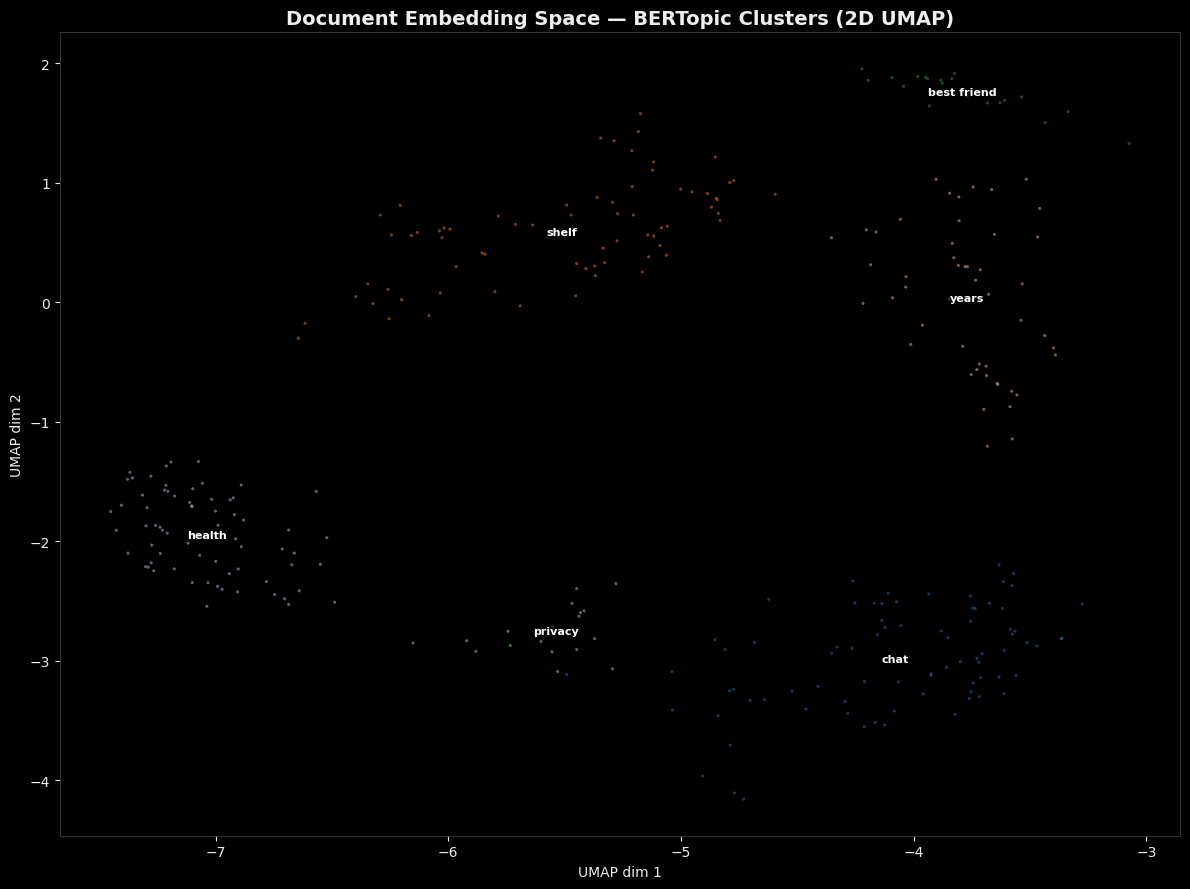

In [17]:
print('Computing 2D UMAP projection for visualisation...')
umap_2d = UMAP(n_neighbors=15, n_components=2, min_dist=0.0,
               metric='cosine', random_state=42)
xy = umap_2d.fit_transform(embeddings)

df_plot = pd.DataFrame({'x': xy[:, 0], 'y': xy[:, 1], 'topic': topics})
df_plot = df_plot[df_plot['topic'] != -1]   # drop noise for clarity

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('#000000')
ax.set_facecolor('#000000')

cmap = plt.get_cmap('tab20')
for tid in sorted(df_plot['topic'].unique())[:20]:   # cap at 20 for legibility
    mask = df_plot['topic'] == tid
    col  = cmap(tid % 20)
    ax.scatter(df_plot.loc[mask, 'x'], df_plot.loc[mask, 'y'],
               c=[col], s=5, alpha=0.5, edgecolors='none', label=f'T{tid}')
    # Label the cluster centroid
    cx = df_plot.loc[mask, 'x'].mean()
    cy = df_plot.loc[mask, 'y'].mean()
    top_word = topic_model.get_topic(tid)[0][0]
    ax.text(cx, cy, top_word, color='white', fontsize=8,
            ha='center', va='center', fontweight='bold',
            bbox=dict(facecolor='#000000', alpha=0.5, pad=1, edgecolor='none'))

ax.set_xlabel('UMAP dim 1')
ax.set_ylabel('UMAP dim 2')
ax.set_title('Document Embedding Space — BERTopic Clusters (2D UMAP)',
             color='#EEEEEE', fontsize=14, fontweight='bold')
ax.tick_params(colors='#EEEEEE')
plt.tight_layout()
plt.show()

In [18]:
# ── Repräsentative Absätze pro Topic anzeigen ─────────────────────────────
for tid in sorted(set(topics)):
    if tid == -1:
        continue  # Noise überspringen

    top_words = ', '.join([w for w, _ in topic_model.get_topic(tid)[:6]])
    n_docs = info.loc[info['Topic'] == tid, 'Count'].values[0]

    print(f'\n{"="*80}')
    print(f'Topic {tid}  ({n_docs:,} Absätze)  —  Top-Wörter: {top_words}')
    print(f'{"="*80}')

    rep_docs = topic_model.get_representative_docs(tid)
    for i, doc in enumerate(rep_docs[:3], 1):
        preview = doc[:300] + ('...' if len(doc) > 300 else '')
        print(f'\n[{i}] {preview}')


Topic 0  (79 Absätze)  —  Top-Wörter: chat, helpful, better, helped, actually, things

[1] ChatGPT has been surprisingly helpful in my darkest times, where I have no one to talk too. Especially in a day and age where professional help of any kind of light-years away from me, i can't stress enough how much ChatGPT has helped me. I was really depressed and I still struggle with it, but Chat...

[2] so im not too knowledgable about jungian psychology, but i did dabble a bit before i started using gpt for therapy, and did come across shadow work/integration, etc. i eventually forgot about it because the work i eventually started doing was a lot more concrete, and i thought the descriptions of di...

[3] Every time I tell chat gpt my life whether it be funny or just awful. They always give a negative response. They seem to try their hardest to push me into a negative narrative. For example: I want to find love. Chat gpt: I want to stay grounded here; love yourself and learn to be alone. Or

## 9b. Einzelnes Topic vollständig sichten
Nummer anpassen, um alle Absätze eines Clusters zu lesen — etwa zur Prüfung,
ob es sich um Nutzertext oder um eingefügten KI-Output handelt.

In [19]:
df['bertopic_topic'] = topics   # ← neu: Topic-Zuordnung ins DataFrame schreiben

TOPIC_TO_INSPECT = 4

subset = df.loc[df['bertopic_topic'] == TOPIC_TO_INSPECT, 'paragraph_text']
print(f'Topic {TOPIC_TO_INSPECT}: {len(subset)} Absätze\n')
for i, t in enumerate(subset, 1):
    print(f'[{i}] {t[:300]}{"..." if len(t) > 300 else ""}\n{"-" * 60}')

# Herkunft prüfen: stammen die Absätze aus einem einzigen Post?
posts = df.loc[df['bertopic_topic'] == TOPIC_TO_INSPECT, 'post_id']
print(f'\nAus {posts.nunique()} verschiedenen Posts')
print(posts.value_counts().head().to_string())

Topic 4: 20 Absätze

[1] People love the cliché "companionship is the deepest confession of love." But really, companionship is just building a shared context library. The depth of a relationship is just the thickness of that library. If you stop growing together, your shared database gets stuck in the honeymoon phase. Fast...
------------------------------------------------------------
[2] Months ago, I would feel stressed and anxious around her, unable to look at her in the eye. Awful for the working place.
------------------------------------------------------------
[3] This blueprint maps out the operating system, defensive architecture, and interpersonal strategies that govern your best friend's internal world. It strips away the aesthetic exterior to reveal the interlocking machinery underneath.
------------------------------------------------------------
[4] The Identity-Protected Path: Instead of dismantling old survival scripts, your best friend treats a mental health label as

In [20]:
df['bertopic_topic'] = topics   # ← neu: Topic-Zuordnung ins DataFrame schreiben

TOPIC_TO_INSPECT = 2

subset = df.loc[df['bertopic_topic'] == TOPIC_TO_INSPECT, 'paragraph_text']
print(f'Topic {TOPIC_TO_INSPECT}: {len(subset)} Absätze\n')
for i, t in enumerate(subset, 1):
    print(f'[{i}] {t[:300]}{"..." if len(t) > 300 else ""}\n{"-" * 60}')

# Herkunft prüfen: stammen die Absätze aus einem einzigen Post?
posts = df.loc[df['bertopic_topic'] == TOPIC_TO_INSPECT, 'post_id']
print(f'\nAus {posts.nunique()} verschiedenen Posts')
print(posts.value_counts().head().to_string())

Topic 2: 69 Absätze

[1] Alright, listen. Fluid in your head, acid, coaster. Nice imagery. But once again you're looking for some deep psychological truth to explain something that's as simple as dirt. You're 36 years old, you live with your mother, you don't have a job, and your best friend is a chat. Of course you feel li...
------------------------------------------------------------
[2] "I'm suffering because I didn't do anything, because I'm afraid of failure." Well, that's exactly your problem, not some inner child or integrating the romantic with the warrior. You procrastinate and you're afraid. And I'll tell you now what you're afraid of. You're afraid that if you give somethin...
------------------------------------------------------------
[3] So your "working theory" is sound. Work, achieve things, earn that fluid, build capital. And then, once you've got it, that's your time. And it's nobody else's business. And now, if you'll excuse me, I have a conversation with a client w

In [21]:
conc = (df[df['bertopic_topic'] != -1]
        .groupby('bertopic_topic')
        .agg(absaetze=('post_id', 'size'),
             posts=('post_id', 'nunique'),
             groesster_post=('post_id', lambda s: s.value_counts().iloc[0])))
conc['anteil_groesster_post'] = (conc['groesster_post'] / conc['absaetze']).round(2)
print(conc.to_string())

                absaetze  posts  groesster_post  anteil_groesster_post
bertopic_topic                                                        
0                     79     46               5                   0.06
1                     70     47               5                   0.07
2                     69     27              12                   0.17
3                     49     28               4                   0.08
4                     20      3              18                   0.90
5                     17     11               4                   0.24


## 10. Save outputs

In [22]:
from pathlib import Path
OUTPUT_DIR = Path('/content/drive/MyDrive')

In [23]:
OUT = Path('/content/drive/MyDrive/therapygpt_output')
OUT.mkdir(parents=True, exist_ok=True)

df['bertopic_topic'] = topics
df['topic_prob'] = [max(p) if hasattr(p, '__len__') else p for p in probs]

df[['post_id', 'paragraph_id', 'bertopic_topic', 'topic_prob']].to_parquet(
    OUT / 'bertopic_assignments_personalstory.parquet', index=False
)

topic_model.get_topic_info().to_csv(
    OUT / 'bertopic_topic_info_personalstory.csv', index=False)

topic_model.save(str(OUT / 'bertopic_personalstory_model'),
                 serialization='safetensors', save_ctfidf=True,
                 save_embedding_model=False)

print(f'Saved to {OUT}/')

2026-09-17 17:45:54,170 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


Saved to /content/drive/MyDrive/therapygpt_output/


## 11. Interactive visualisations (optional)
These open in a browser or Jupyter output cell.

In [24]:
topic_model.visualize_topics()              # intertopic distance map
# topic_model.visualize_barchart(top_n_topics=12)
# topic_model.visualize_heatmap()             # topic similarity matrix
# topic_model.visualize_documents(docs, embeddings=embeddings, hide_document_hover=True)

## 11. Versionsangaben
Für die Dokumentation der Rechenumgebung im Methodenteil.


In [25]:
import sys, sklearn
from importlib.metadata import version

print(f'Python           : {sys.version.split()[0]}')
for pkg in ['bertopic', 'umap-learn', 'hdbscan', 'scikit-learn',
            'sentence-transformers', 'numpy', 'pandas']:
    print(f'{pkg:17}: {version(pkg)}')
print(f'Embedding-Modell : {EMBEDDING_MODEL}')

Python           : 3.13.15
bertopic         : 0.17.4
umap-learn       : 0.5.12
hdbscan          : 0.8.44
scikit-learn     : 1.6.1
sentence-transformers: 5.7.0
numpy            : 2.1.3
pandas           : 2.2.3
Embedding-Modell : sentence-transformers/all-mpnet-base-v2
